## SETUP ##


In [3]:
import psycopg2
import pandas as pd

# Shared connection parameters — change these to match your setup
DB_CONFIG = {
    
    "host":     "localhost",
    "dbname": "bank_app_review",
    "user":     "ilham",
    "password": "12345678",
    "port": 5432
}

In [ ]:
conn = psycopg2.connect(**DB_CONFIG)
cur  = conn.cursor()

# 1. Create a custom schema and switch to it automatically
cur.execute("CREATE SCHEMA IF NOT EXISTS bank_data;")
cur.execute("SET search_path TO bank_data;")

# --- bank_app_review table ---
cur.execute("""
    CREATE TABLE IF NOT EXISTS bank_app_review (
        bank_id   SERIAL PRIMARY KEY,
        bank_name VARCHAR(255) UNIQUE
    );
""")

# --- reviews table ---
cur.execute("""
    CREATE TABLE IF NOT EXISTS reviews (
        review_id     SERIAL PRIMARY KEY,
        bank_id       INT REFERENCES bank_app_review(bank_id),
        review_text   TEXT,
        rating        INT,
        review_date   DATE,
        source        VARCHAR(50)
    );
""")

conn.commit()
cur.close()
conn.close()

print("Tables successfully created inside the custom 'bank_data' schema!")


Tables successfully created inside the custom 'bank_data' schema!


## LOAD CSV FILE TO PANDAS ##

In [ ]:
import pandas as pd
import glob

# 1. Load the main bank lookup table
# This maps bank_id to bank_name
banks_df = pd.read_csv("banks.csv")
print("Successfully loaded banks.csv. Shape:", banks_df.shape)

Successfully loaded banks.csv. Shape: (3, 2)


In [ ]:
import os
print("Python is looking inside:", os.getcwd())
print("Files Python can see:", os.listdir())


Python is looking inside: c:\Users\yared\Desktop\week2\notebooks
Files Python can see: ['abbysinia.ipynb', 'abbysinia_bank_reviews.csv', 'AWASH.ipynb', 'awash_bank_reviews.csv', 'bank_review.ipynb', 'CBE.ipynb', 'commercial_bank_reviews.csv', 'data', 'init.py', 'README.md', 'test_pipeline.py']


In [ ]:
import pandas as pd
import glob

# Use the absolute Windows path to load the file explicitly
banks_df = pd.read_csv("banks.csv")
print("Successfully loaded banks.csv. Shape:", banks_df.shape)

# Load your 3 review files using explicit absolute path formatting
# (Change the names below to match your exact file names on your computer)
bank1_df = pd.read_csv("awash_bank_reviews.csv")
bank2_df = pd.read_csv("commercial_bank_reviews.csv")
bank3_df = pd.read_csv("abbysinia_bank_reviews.csv")

print("All individual DataFrames loaded successfully!")


Successfully loaded banks.csv. Shape: (3, 2)
All individual DataFrames loaded successfully!


In [ ]:
# Add a column indicating which bank the data belongs to before merging
# (Assuming your 3 individual files have columns like 'text', 'rating', 'date', 'source')
bank1_df['source'] = 'Bank 1 App'
bank2_df['source'] = 'Bank 2 App'
bank3_df['source'] = 'Bank 3 App'

# Combine all 3 sets into a single master review table
reviews_df = pd.concat([bank1_df, bank2_df, bank3_df], ignore_index=True)
print("Total rows combined from all 3 scrapers:", reviews_df.shape[0])


Total rows combined from all 3 scrapers: 1500


In [ ]:
print(reviews_df.head())

                               reviewId            userName  \
0  d251dd23-f516-4c34-8be9-2f6205ff04a1         Nyalite Tut   
1  911ed0ae-df98-4199-ac01-e8b91731cfe2        Solomon Wale   
2  3c6b9df9-ff20-4ccb-b918-4336a0cce1d6           Wende Man   
3  15364398-e025-435a-8fcc-b6ce863df75d          Abera Mamo   
4  f2afbfce-ee6d-4a33-8d20-a53a820c15d5  Dhaloota Boruu1122   

                                           userImage  \
0  https://play-lh.googleusercontent.com/a/ACg8oc...   
1  https://play-lh.googleusercontent.com/a-/ALV-U...   
2  https://play-lh.googleusercontent.com/a/ACg8oc...   
3  https://play-lh.googleusercontent.com/a-/ALV-U...   
4  https://play-lh.googleusercontent.com/a/ACg8oc...   

                                             content  score  thumbsUpCount  \
0                                   good application      5              0   
1                                      How i can use      5              0   
2                                Wende. Weju. Meku

In [ ]:
import psycopg2
from psycopg2.extras import execute_values

# 1. Establish your database connection
conn = psycopg2.connect(**DB_CONFIG)
cur = conn.cursor()

try:
    # Activate your custom schema
    cur.execute("SET search_path TO bank_data;")
    
    # 2. STEP ONE: Insert the Bank Names into the parent table
    # Using 'ON CONFLICT DO NOTHING' ensures if you rerun this cell, it won't crash on duplicate bank names
    banks_to_insert = [("Commercial Bank of Ethiopia",), ("Awash Bank",), ("Bank of Abyssinia",)]
    
    execute_values(cur, """
        INSERT INTO bank_app_review (bank_name) 
        VALUES %s 
        ON CONFLICT (bank_name) DO NOTHING;
    """, banks_to_insert)
    
    # Fetch the auto-generated bank_ids from the database to create a Python lookup mapping
    cur.execute("SELECT bank_id, bank_name FROM bank_app_review;")
    bank_lookup = {name: b_id for b_id, name in cur.fetchall()}
    print("Database Bank Mapping:", bank_lookup)
    
    # 3. STEP TWO: Map the reviews DataFrame to match your database schema
    # Map your combined DataFrame column names to the database fields:
    # Example: If your dataframe column is 'review', map it to 'review_text'
    column_mapping = {
        'reviewDescription': 'review_text',  # <-- Change 'reviewDescription' to your actual column name
        'score': 'rating',                  # <-- Change 'score' to your actual column name
        'at': 'review_date',                # <-- Change 'at' to your actual column name
        'source': 'source'
    }
    
    # Map your DataFrames to include the correct numeric bank_id column using your source text
    # (Adjust 'Commercial Bank of Ethiopia', etc., to match whatever string is in your 'source' column)
    source_to_name = {
        'CBE': 'Commercial Bank of Ethiopia',
        'Awash': 'Awash Bank',
        'Abyssinia': 'Bank of Abyssinia'
    }
    
    # Process your reviews DataFrame to line up with the database structure
    # 1. Map source keys to canonical bank names, then map those names to database IDs
    # (Replace 'source' below if your column identifying the bank has a different header)
    reviews_df['bank_id'] = reviews_df['source'].map(source_to_name).map(bank_lookup)
    
    # Rename columns to match database names exactly
    db_ready_df = reviews_df.rename(columns=column_mapping)
    
    # Extract only the specific columns required by your SQL reviews table structure
    final_columns = ['bank_id', 'review_text', 'rating', 'review_date', 'source']
    insert_data = db_ready_df[final_columns].dropna(subset=['bank_id']).values.tolist()
    
    # 4. STEP THREE: Batch insert all 1,500 reviews efficiently
    print(f"Beginning batch insertion of {len(insert_data)} review records...")
    
    execute_values(cur, """
        INSERT INTO reviews (bank_id, review_text, rating, review_date, source)
        VALUES %s;
    """, insert_data)
    
    # Commit the transactions permanently to the disk
    conn.commit()
    print("🎉 All 1,500 records inserted successfully into PostgreSQL!")

except Exception as e:
    conn.rollback()
    print("❌ Database insertion failed. Transaction rolled back safely.")
    print("Error Details:", e)

finally:
    cur.close()
    conn.close()


Database Bank Mapping: {'Commercial Bank of Ethiopia': 1, 'Awash Bank': 2, 'Bank of Abyssinia': 3}
❌ Database insertion failed. Transaction rolled back safely.
Error Details: "['review_text'] not in index"


In [ ]:
print(reviews_df.head())

                               reviewId            userName  \
0  d251dd23-f516-4c34-8be9-2f6205ff04a1         Nyalite Tut   
1  911ed0ae-df98-4199-ac01-e8b91731cfe2        Solomon Wale   
2  3c6b9df9-ff20-4ccb-b918-4336a0cce1d6           Wende Man   
3  15364398-e025-435a-8fcc-b6ce863df75d          Abera Mamo   
4  f2afbfce-ee6d-4a33-8d20-a53a820c15d5  Dhaloota Boruu1122   

                                           userImage  \
0  https://play-lh.googleusercontent.com/a/ACg8oc...   
1  https://play-lh.googleusercontent.com/a-/ALV-U...   
2  https://play-lh.googleusercontent.com/a/ACg8oc...   
3  https://play-lh.googleusercontent.com/a-/ALV-U...   
4  https://play-lh.googleusercontent.com/a/ACg8oc...   

                                             content  score  thumbsUpCount  \
0                                   good application      5              0   
1                                      How i can use      5              0   
2                                Wende. Weju. Meku

## setup for analysis ##

In [6]:
# Cell 1: Comprehensive Imports
import warnings, re, os, json
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Download necessary NLTK components
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt', 'wordnet']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
print("Environment ready ✓")

Environment ready ✓


In [7]:
# Cell 2: Configurable Scraper Function
from google_play_scraper import reviews, Sort

# App package IDs for global fintech apps
APPS = {
    ' CBE':  'com.combanketh.mobilebanking',
    'AWASH': 'com.sc.awashpay',
    'ABBYSINIA': 'com.boa.boaMobileBanking',
}

def scrape_fintech_reviews(app_dict, count=500):
    """Fetches recent reviews for a dictionary of apps."""
    all_reviews = []
    for name, pkg in app_dict.items():
        try:
            res, _ = reviews(pkg, lang='en', country='us', sort=Sort.NEWEST, count=count)
            for r in res:
                all_reviews.append({
                    'app': name,
                    'review': r['content'],
                    'rating': r['score'],
                    'date': r['at'],
                    'thumbs': r['thumbsUpCount']
                })
            print(f"  Scraped {len(res)} reviews for {name}")
        except Exception as e:
            print(f"  Failed to scrape {name}: {e}")
    return pd.DataFrame(all_reviews)

# Fetching reviews
df_raw = scrape_fintech_reviews(APPS, count=500)
print(f"\nTotal raw reviews: {len(df_raw)}")

  Scraped 500 reviews for  CBE
  Scraped 500 reviews for AWASH
  Scraped 500 reviews for ABBYSINIA

Total raw reviews: 1500


In [8]:
# Cell 3: Preprocessing Logic
import nltk
nltk.download('punkt_tab')

def modular_nlp_pipeline(text):
    # 1. Cleaning
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Stop-word removal & Lemmatization
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    processed = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(processed)

# Apply cleaning
print("Running modular preprocessing...")
df_raw['clean_text'] = df_raw['review'].apply(modular_nlp_pipeline)

# Drop invalid/too short reviews
df_clean = df_raw[df_raw['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_clean)}")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\yared\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Running modular preprocessing...
Final cleaned dataset size: 1390


## ADVANCED CLEANING ##


In [9]:
# Cell 3: Robust Cleaning & Normalisation
def robust_clean(df):
    # 1. Strip Whitespaces & Trailing Zeros
    for col in df.select_dtypes(include=['object']):
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].str.replace(r'\.0$', '', regex=True)

    # 2. Date Normalisation
    df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.strftime('%Y-%m-%d')

    # 3. Handle Missing Values
    print(f"Nulls before: {df.isnull().sum().sum()}")
    df = df.dropna(subset=['review', 'rating'])

    # 4. Filter empty/short reviews
    df = df[df['review'].str.len() > 2]

    print(f"Final Nulls: {df.isnull().sum().sum()}")
    print(f"Final Dataset Shape: {df.shape}")
    return df.reset_index(drop=True)

df_clean = robust_clean(df_raw.copy())


Nulls before: 0
Final Nulls: 0
Final Dataset Shape: (1457, 6)


## Rating & Data Quality Distribution

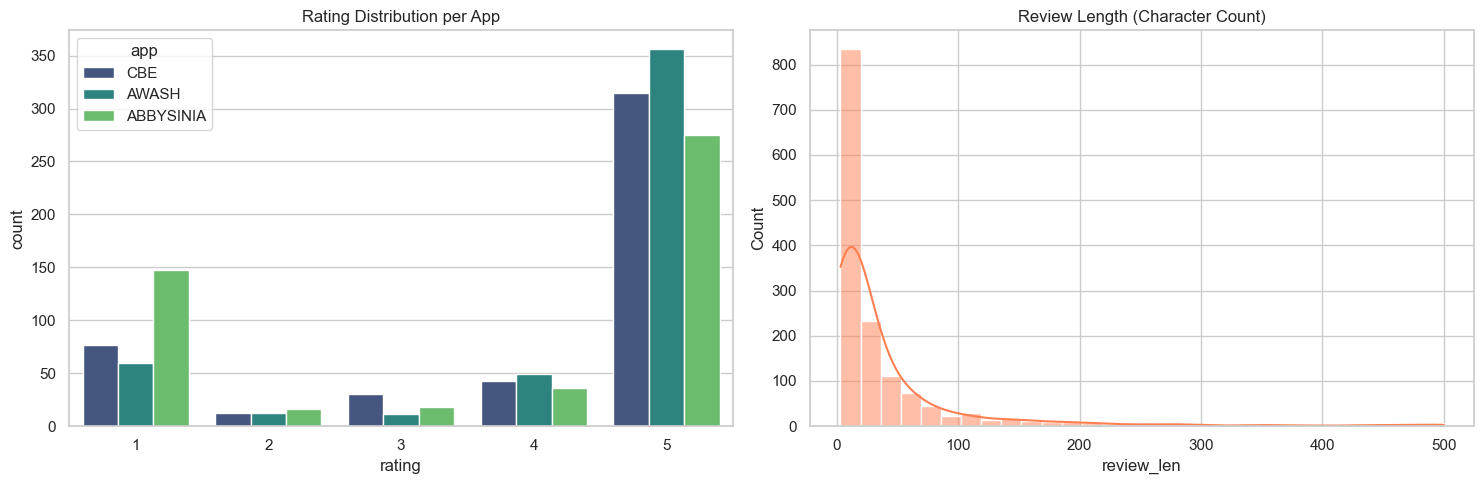

In [10]:
# Cell 4: Visualizing Distributions
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Rating per App
sns.countplot(data=df_clean, x='rating', hue='app', palette='viridis', ax=ax[0])
ax[0].set_title('Rating Distribution per App')

# Review Length
df_clean['review_len'] = df_clean['review'].str.len()
sns.histplot(df_clean['review_len'], bins=30, kde=True, ax=ax[1], color='coral')
ax[1].set_title('Review Length (Character Count)')

plt.tight_layout(); plt.show()

## NLP Pipeline: Keyword Extraction

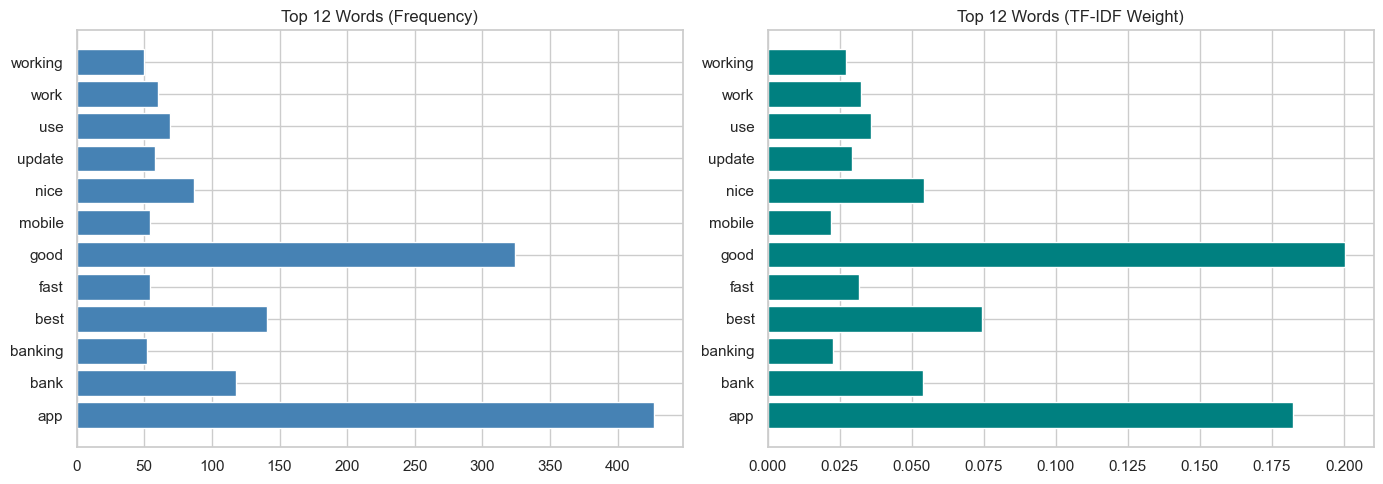

In [11]:
# Frequency (BoW) vs TF-IDF
tfidf_vec = TfidfVectorizer(max_features=12, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(df_clean['clean_text'])

cv_vec = CountVectorizer(max_features=12, stop_words='english')
X_cv = cv_vec.fit_transform(df_clean['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cv_vec.get_feature_names_out(), X_cv.toarray().sum(axis=0), color='steelblue')
axes[0].set_title('Top 12 Words (Frequency)')

axes[1].barh(tfidf_vec.get_feature_names_out(), X_tfidf.toarray().mean(axis=0), color='teal')
axes[1].set_title('Top 12 Words (TF-IDF Weight)')

plt.tight_layout(); plt.show()

##  N-gram Analysis (Context Discovery)

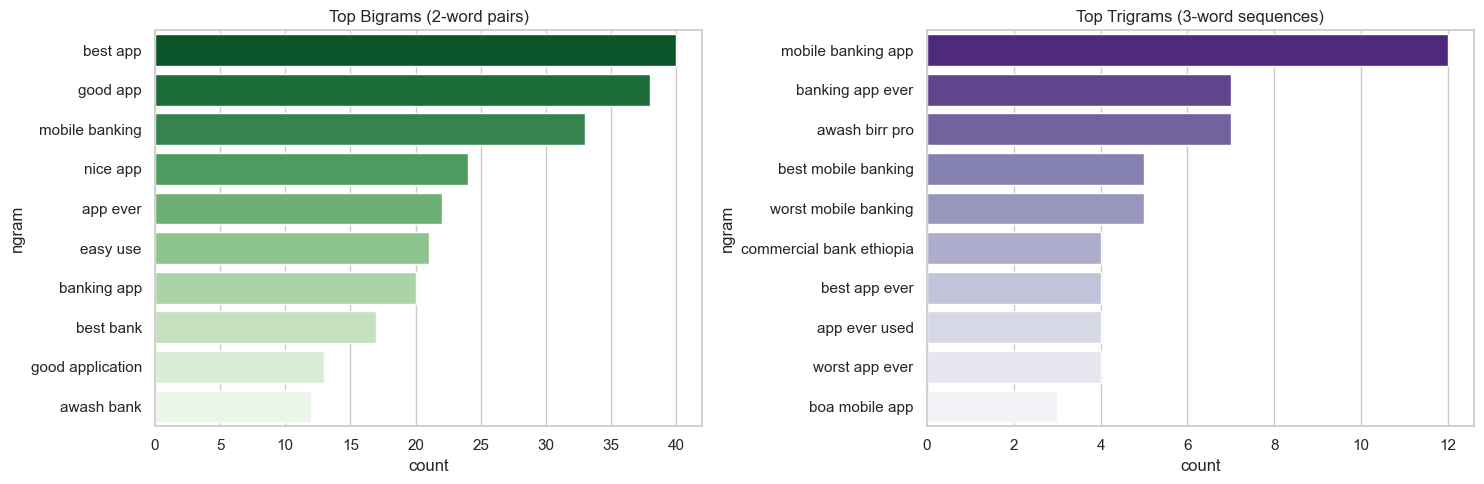

In [12]:
def get_top_ngrams(corpus, n, k=10):
    vec = CountVectorizer(ngram_range=(n,n), max_features=100)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(k)

bi = get_top_ngrams(df_clean['clean_text'], 2)
tri = get_top_ngrams(df_clean['clean_text'], 3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Bigrams (2-word pairs)')
sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top Trigrams (3-word sequences)')
plt.tight_layout(); plt.show()

## POS Tagging & Noun Extraction

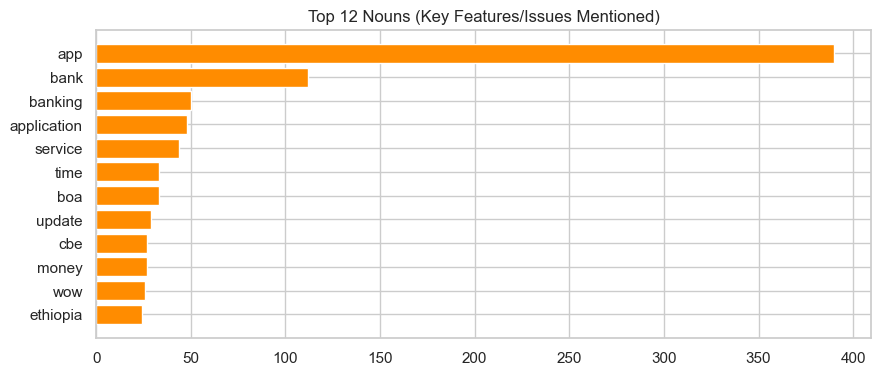

In [13]:
# Identifying Product Features (Nouns)
import nltk
from nltk import word_tokenize, pos_tag
from collections import Counter
import matplotlib.pyplot as plt

# Download the specific tagger if it's not already downloaded
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

def extract_nouns(text):
    tokens = word_tokenize(text)
    return [w.lower() for w, p in pos_tag(tokens) if p.startswith('NN') and len(w) > 2 and w.lower() not in stop_words]

df_clean['nouns'] = df_clean['review'].apply(extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

## Word Cloud Visualization

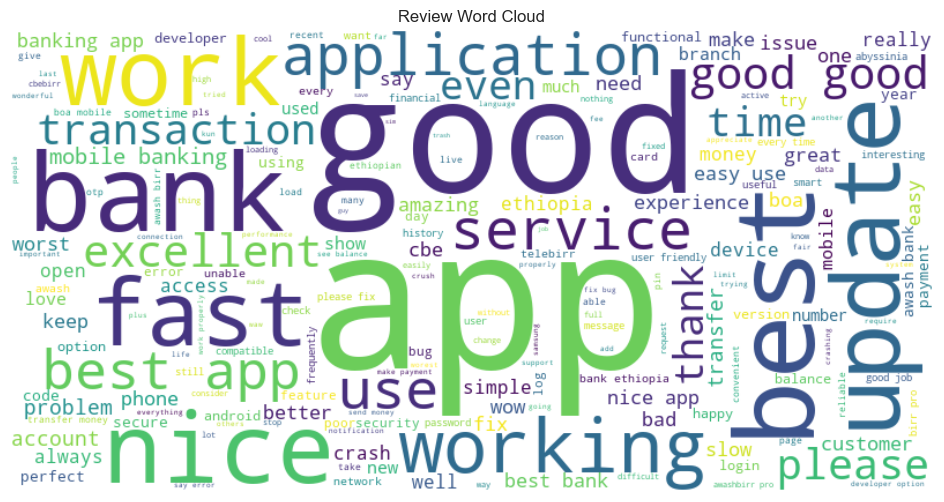

In [14]:
# Cell 8: Word Cloud
text_combined = " ".join(df_clean['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()

## Multi-Model Sentiment Analysis

In [15]:
# Sentiment Application
df_clean['vader_compound'] = df_clean['review'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_clean['tb_polarity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_clean['tb_subjectivity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

def get_label(s):
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

df_clean['sentiment'] = df_clean['vader_compound'].apply(get_label)
print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))

VADER Distribution:
 sentiment
positive    0.61
neutral     0.27
negative    0.12
Name: proportion, dtype: float64


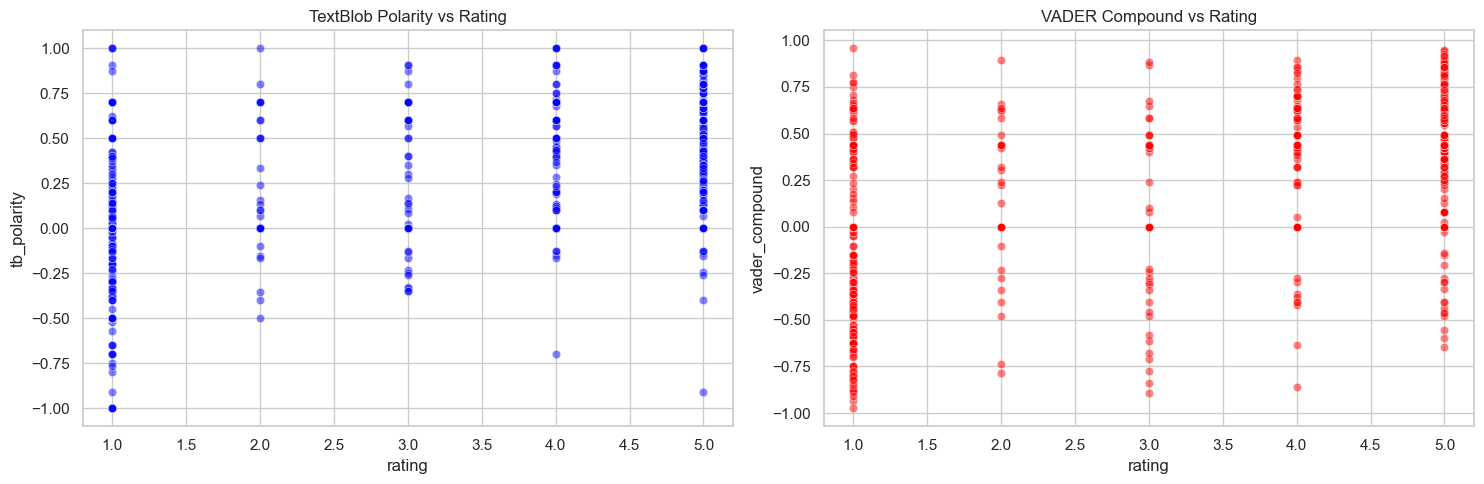

In [16]:
# Sentiment vs. Star Rating
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# TextBlob Scatter
sns.scatterplot(data=df_clean, x='rating', y='tb_polarity', alpha=0.5, ax=axes[0], color='blue')
axes[0].set_title('TextBlob Polarity vs Rating')

# VADER Scatter
sns.scatterplot(data=df_clean, x='rating', y='vader_compound', alpha=0.5, ax=axes[1], color='red')
axes[1].set_title('VADER Compound vs Rating')

plt.tight_layout(); plt.show()

### Transformer-based Sentiment (Template)

In [17]:
# Cell 11: Transformer Pipeline
from tqdm.notebook import tqdm

try:
    from transformers import pipeline
    sent_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

    # Apply transformer to all reviews in df_clean
    transformer_results = []
    # Process in batches to handle memory and speed, if df_clean is very large
    batch_size = 16 # Adjust batch size as needed
    for i in tqdm(range(0, len(df_clean), batch_size), desc="Running Transformer Sentiment"): # Changed desc here
        batch = df_clean['review'].iloc[i:i + batch_size].tolist()
        preds = sent_model(batch)
        transformer_results.extend(preds)

    df_clean['transformer_sentiment_label'] = [p['label'] for p in transformer_results]
    df_clean['transformer_sentiment_score'] = [p['score'] if p['label'] == 'POSITIVE' else -p['score'] for p in transformer_results]

    print("\nTransformer Sentiment Distribution:")
    print(df_clean['transformer_sentiment_label'].value_counts(normalize=True).round(2))

except Exception as e:
    print(f"Transformer skipped: {e}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Running Transformer Sentiment:   0%|          | 0/92 [00:00<?, ?it/s]


Transformer Sentiment Distribution:
transformer_sentiment_label
POSITIVE    0.64
NEGATIVE    0.36
Name: proportion, dtype: float64


 Sentiment Model Comparison: VADER, TextBlob, and Transformer

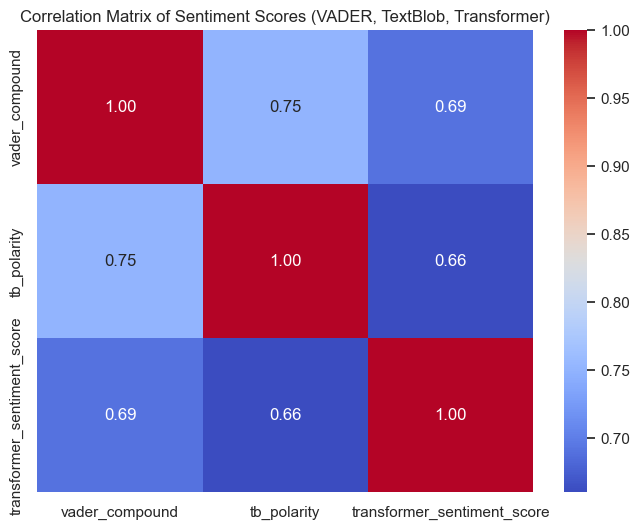

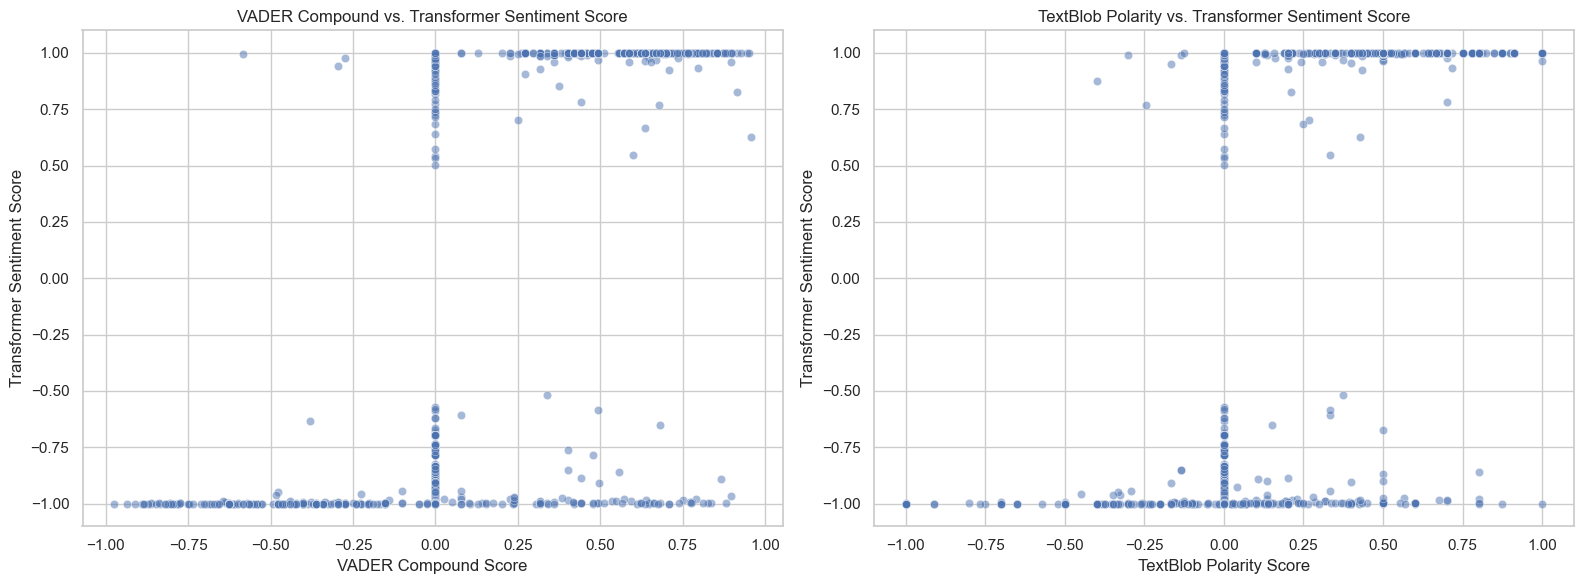

In [18]:
# Ensure transformer_sentiment_score is available
if 'transformer_sentiment_score' not in df_clean.columns:
    print("Transformer sentiment scores not available for comparison.")
else:
    # Create a DataFrame for correlation
    sentiment_scores = df_clean[['vader_compound', 'tb_polarity', 'transformer_sentiment_score']]

    # Calculate the correlation matrix
    correlation_matrix = sentiment_scores.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Sentiment Scores (VADER, TextBlob, Transformer)')
    plt.show()

    # Plotting scatter plots for pairwise comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(data=df_clean, x='vader_compound', y='transformer_sentiment_score', alpha=0.5, ax=axes[0])
    axes[0].set_title('VADER Compound vs. Transformer Sentiment Score')
    axes[0].set_xlabel('VADER Compound Score')
    axes[0].set_ylabel('Transformer Sentiment Score')

    sns.scatterplot(data=df_clean, x='tb_polarity', y='transformer_sentiment_score', alpha=0.5, ax=axes[1])
    axes[1].set_title('TextBlob Polarity vs. Transformer Sentiment Score')
    axes[1].set_xlabel('TextBlob Polarity Score')
    axes[1].set_ylabel('Transformer Sentiment Score')

    plt.tight_layout()
    plt.show()

In [20]:
# Comparing Sentiment Distributions

if 'transformer_sentiment_label' not in df_clean.columns:
    print("Transformer sentiment labels not available for comparison.")
else:
    print("\n--- Sentiment Label Distributions ---")
    print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))
    print("\nTextBlob Polarity Distribution (thresholded at +/-0.05):\n")
    def get_tb_label(s):
        return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')
    print(df_clean['tb_polarity'].apply(get_tb_label).value_counts(normalize=True).round(2))
    print("\nTransformer Distribution:\n", df_clean['transformer_sentiment_label'].value_counts(normalize=True).round(2))


--- Sentiment Label Distributions ---
VADER Distribution:
 sentiment
positive    0.61
neutral     0.27
negative    0.12
Name: proportion, dtype: float64

TextBlob Polarity Distribution (thresholded at +/-0.05):

tb_polarity
positive    0.61
neutral     0.30
negative    0.08
Name: proportion, dtype: float64

Transformer Distribution:
 transformer_sentiment_label
POSITIVE    0.64
NEGATIVE    0.36
Name: proportion, dtype: float64


## Aggregating Sentiment Scores by App and Star Rating

rating,1,2,3,4,5
app,,,,,
ABBYSINIA,-0.179111,0.055212,0.116389,0.309881,0.352129
AWASH,-0.018177,0.142625,0.215073,0.352971,0.402599
CBE,-0.055329,0.201417,-0.070527,0.197749,0.398957


rating,1,2,3,4,5
app,,,,,
ABBYSINIA,-0.105200,0.112909,0.216715,0.399144,0.469819
AWASH,0.045046,0.191667,0.328067,0.367096,0.466404
CBE,-0.006328,0.220699,0.153838,0.288533,0.511068


rating,1,2,3,4,5
app,,,,,
ABBYSINIA,-0.825862,-0.563670,-0.238850,0.071962,0.631482
AWASH,-0.615693,-0.494238,-0.084621,0.604788,0.652656
CBE,-0.553393,-0.683377,-0.388233,-0.087301,0.735304


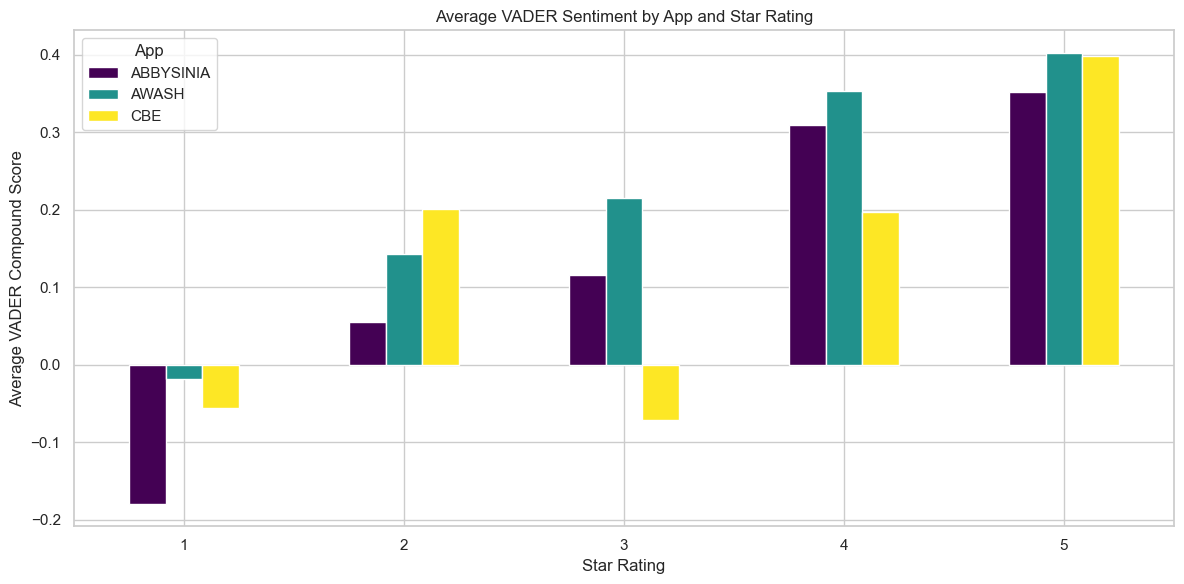

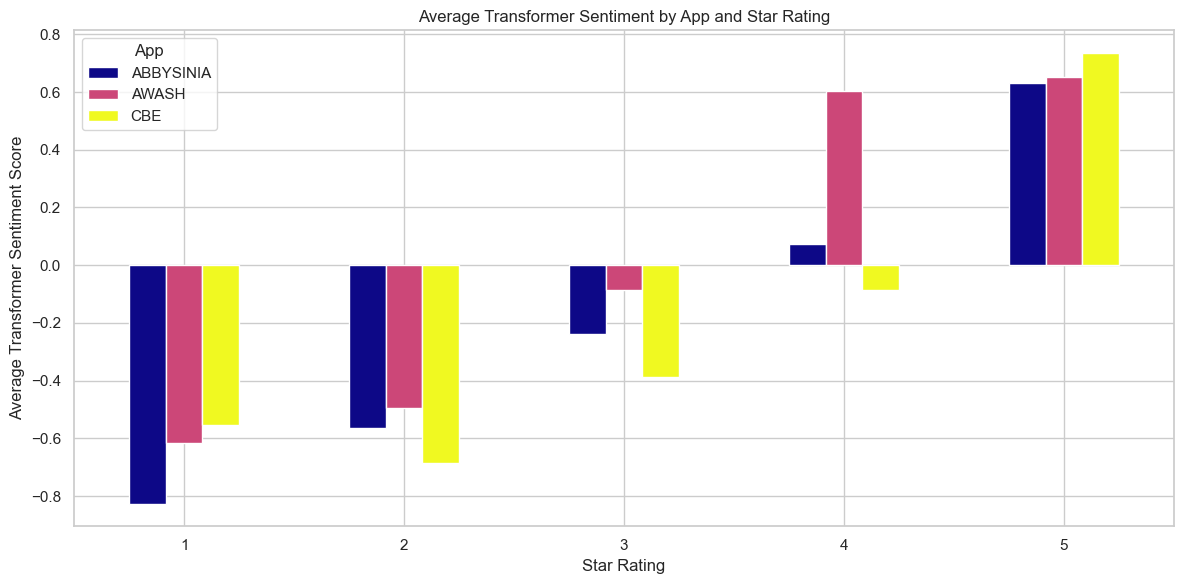

In [21]:
# Aggregate VADER sentiment scores by app and star rating
vader_agg_sentiment = df_clean.groupby(['app', 'rating'])['vader_compound'].mean().unstack()
display(vader_agg_sentiment)

# Aggregate TextBlob polarity scores by app and star rating
tb_agg_sentiment = df_clean.groupby(['app', 'rating'])['tb_polarity'].mean().unstack()
display(tb_agg_sentiment)

# Aggregate Transformer sentiment scores by app and star rating
transformer_agg_sentiment = df_clean.groupby(['app', 'rating'])['transformer_sentiment_score'].mean().unstack()
display(transformer_agg_sentiment)

# Visualize VADER sentiment by app and rating
vader_agg_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Average VADER Sentiment by App and Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average VADER Compound Score')
plt.xticks(rotation=0)
plt.legend(title='App')
plt.tight_layout()
plt.show()

# Visualize Transformer sentiment by app and rating
transformer_agg_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='plasma')
plt.title('Average Transformer Sentiment by App and Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Transformer Sentiment Score')
plt.xticks(rotation=0)
plt.legend(title='App')
plt.tight_layout()
plt.show()

### Thematic Analysis (Actionable Topics)

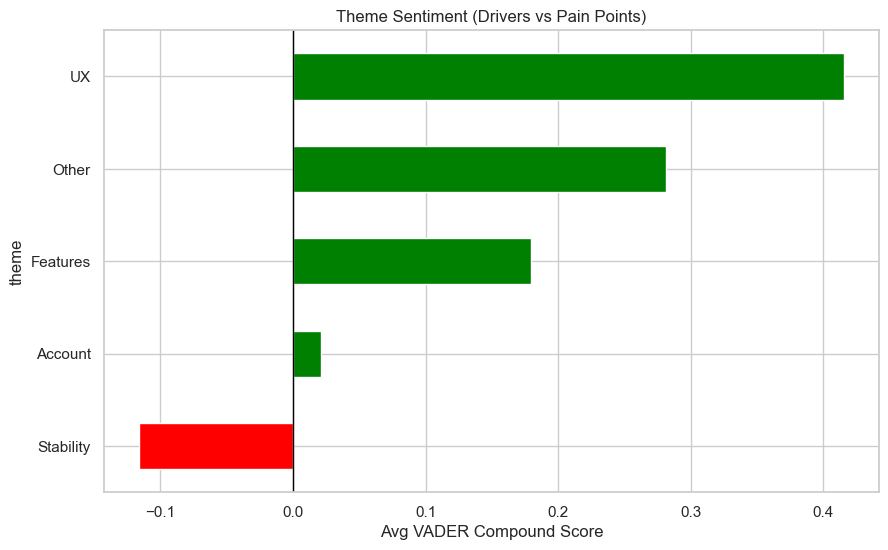

In [25]:
# Cell 12: Business Theme Mapping
THEME_MAP = {
    'Stability': ['crash', 'freeze', 'bug', 'error', 'slow', 'stuck', 'failed'],
    'Account': ['login', 'otp', 'password', 'account', 'verify', 'sign'],
    'UX': ['ui', 'interface', 'clean', 'easy', 'navigation', 'design'],
    'Features': ['transfer', 'payment', 'bill', 'card', 'wallet', 'money']
}

def get_theme(txt):
    txt = txt.lower()
    for theme, keywords in THEME_MAP.items():
        if any(w in txt for w in keywords): return theme
    return 'Other'

df_clean['theme'] = df_clean['review'].apply(get_theme)
theme_sent = df_clean.groupby('theme')['vader_compound'].mean().sort_values()

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in theme_sent.values]
theme_sent.plot(kind='barh', color=colors)
plt.title('Theme Sentiment (Drivers vs Pain Points)')
plt.xlabel('Avg VADER Compound Score')
plt.axvline(0, color='black', lw=1)
plt.show()

## Results Export

In [28]:
# Cell 6: Saving Results
output_cols = [ 'review', 'review_text', 'sentiment_label', 'sentiment', 'theme' ]
df_final = df_clean[output_cols]

# Save to CSV
df_final.to_csv('fintech_sentiment_analysis_results.csv', index=False)
print("✓ Pipeline results saved as 'fintech_sentiment_analysis_results.csv'")
df_final.head()

KeyError: "['review_text', 'sentiment_label'] not in index"

In [27]:
print(df_clean.columns.tolist())


['app', 'review', 'rating', 'date', 'thumbs', 'clean_text', 'review_len', 'nouns', 'vader_compound', 'tb_polarity', 'tb_subjectivity', 'sentiment', 'transformer_sentiment_label', 'transformer_sentiment_score', 'theme']


In [30]:
# 1. Create a copy of the data with the columns you actually have
df_final = df_clean[['review', 'transformer_sentiment_label', 'transformer_sentiment_score', 'theme']].copy()

# 2. Generate the missing 'review_id' column using the dataframe's index
df_final['review_id'] = df_final.index

# 3. Rename the columns to match your assignment instructions exactly
df_final = df_final.rename(columns={
    'review': 'review_text',
    'transformer_sentiment_label': 'sentiment_label',
    'transformer_sentiment_score': 'sentiment_score',
    'theme': 'identified_theme'
})

# 4. Reorder them to match the exact sequence requested
output_cols = ['review_id', 'review_text', 'sentiment_label', 'sentiment_score', 'identified_theme']
df_final = df_final[output_cols]

# 5. Save to CSV
df_final.to_csv('fintech_sentiment_analysis_results.csv', index=False)
print("Assignment CSV generated successfully with exact column names!")
print("✓ Pipeline results saved as 'fintech_sentiment_analysis_results.csv'")
df_final.head()

Assignment CSV generated successfully with exact column names!
✓ Pipeline results saved as 'fintech_sentiment_analysis_results.csv'


,review_id,review_text,sentiment_label,sentiment_score,identified_theme
0,0,excellent,POSITIVE,0.999843,Other
1,1,good luck with your job i,POSITIVE,0.999772,Other
2,2,Ethiopian bank,POSITIVE,0.949511,Other
3,3,best one,POSITIVE,0.999827,Other
4,4,mohammad Ahmed ibro,POSITIVE,0.920996,Other
